In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# SETTING UP THE DF

In [4]:
df = pd.read_parquet('../../data/raw/all_chicago_crimes.parquet')

In [4]:
#just prints the columns and the unique values in primary type
df.columns, df['Primary Type'].unique()

(Index(['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type',
        'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat',
        'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate',
        'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude',
        'Location'],
       dtype='object'),
 array(['MOTOR VEHICLE THEFT', 'THEFT', 'DECEPTIVE PRACTICE', 'BATTERY',
        'BURGLARY', 'ASSAULT', 'CRIMINAL SEXUAL ASSAULT',
        'CRIMINAL DAMAGE', 'NARCOTICS', 'SEX OFFENSE', 'OTHER OFFENSE',
        'PUBLIC PEACE VIOLATION', 'INTERFERENCE WITH PUBLIC OFFICER',
        'WEAPONS VIOLATION', 'CRIMINAL TRESPASS',
        'OFFENSE INVOLVING CHILDREN', 'ROBBERY', 'STALKING',
        'INTIMIDATION', 'HOMICIDE', 'CONCEALED CARRY LICENSE VIOLATION',
        'ARSON', 'KIDNAPPING', 'PUBLIC INDECENCY', 'LIQUOR LAW VIOLATION',
        'PROSTITUTION', 'OBSCENITY', 'HUMAN TRAFFICKING', 'GAMBLING',
        'OTHER NARCOTIC VIOLATION', 'NON-CRIMINAL', 'RITUALIS

# SOME LITTLE MURDER ANALYSIS

In [4]:
murders_df = df[df['Primary Type'] == 'HOMICIDE']

In [5]:
murders_df[['Primary Type', 'ID', 'Description']].groupby('Description').count()

,Primary Type,ID
Description,,
FIRST DEGREE MURDER,14078,14078
INVOLUNTARY MANSLAUGHTER,6,6
RECKLESS HOMICIDE,82,82
SECOND DEGREE MURDER,1,1


In [6]:
murders_df[murders_df['Description'] == 'RECKLESS HOMICIDE'].groupby('Arrest').count()[['ID']]

,ID
Arrest,
False,2
True,80


# ANALYSIS OF RITUALISM<br>
Just a wacky crime type I was unaware of. I did not know that it existed and it is very interesting to me. Unfortunately, there are only a few crime instances, so I do not think we can draw any useful conclusions from this.

In [7]:
ritualism_df = df[df['Primary Type'] == 'RITUALISM']
ritualism_df['Description'].unique(), ritualism_df.shape

(array(['AGG. RITUAL MUTILATION - HANDS, FISTS, FEET, SERIOUS INJURY',
        'AGG RIT MUT: HANDS/FIST/FEET SERIOUS INJURY',
        'AGG RITUAL MUT:HANDGUN', 'AGG RITUAL MUT:OTH DANG WEAPON',
        'AGG RIT MUT: HANDS/FIST/FEET NO/MINOR INJURY',
        'AGG RITUAL MUT:KNIFE/CUTTING I'], dtype=object),
 (24, 22))

In [8]:
ritualism_df.groupby('Arrest').count()[['ID']]

,ID
Arrest,
False,21
True,3


# ANALYSIS OF ARSON<br>
Looks like that only a few of the types are relevant to actually committing the crime.

In [9]:
arson_df = df[df['Primary Type'] == 'ARSON']
arson_df['Description'].unique(), arson_df.shape

(array(['BY FIRE', 'AGGRAVATED', 'BY EXPLOSIVE', 'ATTEMPT ARSON',
        'POSSESSION - EXPLOSIVE / INCENDIARY DEVICE',
        'POSSESSION - CHEMICAL / DRY-ICE DEVICE',
        'POS: EXPLOSIVE/INCENDIARY DEV', 'POS: CHEMICAL/DRY-ICE DEVICE'],
       dtype=object),
 (14564, 22))

In [10]:
arson_df.groupby(['Description', 'Arrest']).count()['ID']

Description                                 Arrest
AGGRAVATED                                  False     1640
                                            True       507
ATTEMPT ARSON                               False     1889
                                            True       339
BY EXPLOSIVE                                False      141
                                            True        11
BY FIRE                                     False     9013
                                            True       861
POS: CHEMICAL/DRY-ICE DEVICE                False       22
                                            True        18
POS: EXPLOSIVE/INCENDIARY DEV               False       41
                                            True        42
POSSESSION - CHEMICAL / DRY-ICE DEVICE      False        1
POSSESSION - EXPLOSIVE / INCENDIARY DEVICE  False       23
                                            True        16
Name: ID, dtype: int64

# ENTIRE DATA SET ANALYSIS

C:\Users\dylan\AppData\Local\Temp\ipykernel_11896\3915203863.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


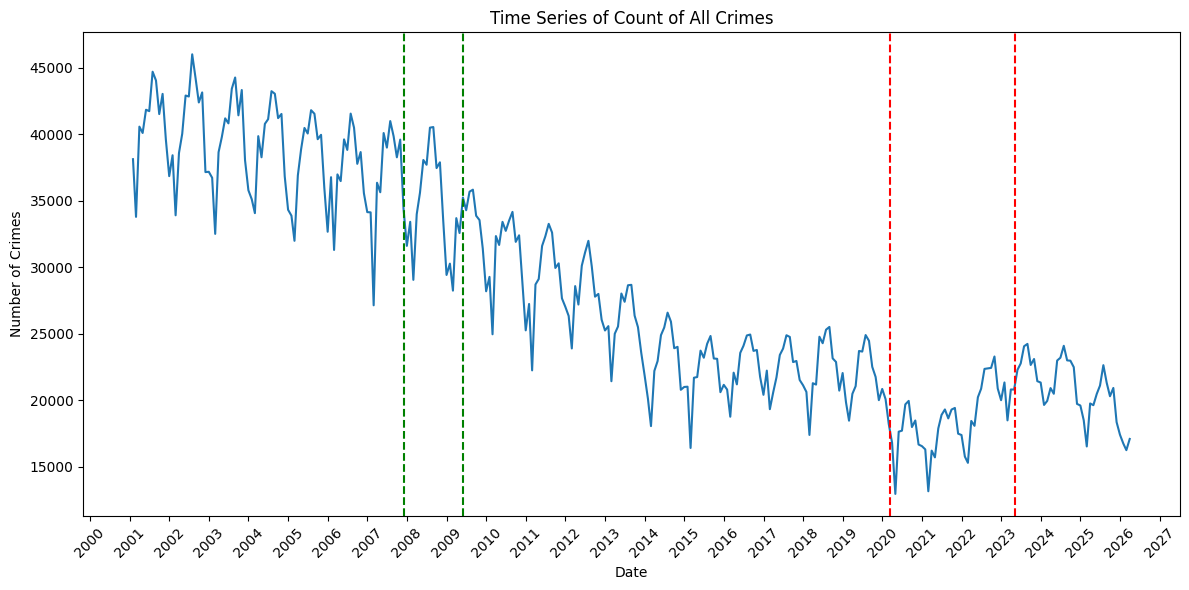

In [6]:
# Convert date column to datetime and sort
df['Date'] = pd.to_datetime(df['Date'])
df_sorted = df.sort_values('Date')

# Count murders per day
murders_per_day = df_sorted.groupby('Date').size()

# Resample to monthly counts
murders_per_month = murders_per_day.resample('ME').sum()

# Create the plot (monthly, connected points)
plt.figure(figsize=(12, 6))
plt.plot(murders_per_month.index, murders_per_month.values, linestyle='-')
import matplotlib.dates as mdates
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.axvline(x=pd.to_datetime('2007-12-01'), color='green', linestyle='--', label='Great Recession Start')
plt.axvline(x=pd.to_datetime('2009-06-01'), color='green', linestyle='--', label='Great Recession End')
plt.axvline(x=pd.to_datetime('2020-03-11'), color='red', linestyle='--', label='Covid Start')
plt.axvline(x=pd.to_datetime('2023-05-05'), color='red', linestyle='--', label='Apr 4, 2019')
plt.xlabel('Date')
plt.ylabel('Number of Crimes')
plt.title('Time Series of Count of All Crimes')
plt.legend()
ax.get_legend().remove()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [1]:
# # Convert date column to datetime and sort
# df['Date'] = pd.to_datetime(df['Date'])
# df_sorted = df.sort_values('Date')

# # Count murders per day
# murders_per_day = df_sorted.groupby('Date').size()

# Resample to monthly counts
murders_per_month = murders_per_day.resample('YE').sum()

crime_df = pd.DataFrame(murders_per_month).reset_index()
crime_df['Date'] = crime_df['Date'].apply(lambda x : x.year)
crime_df = crime_df.set_index('Date')
crime_df.plot(kind='bar', legend=[], title='Yearly Count of All Crimes, 2001-Present', xlabel='Year', ylabel='Count of Crimes', figsize=(10, 10))


# # Create the plot (monthly, connected points)
# plt.figure(figsize=(12, 6))
# plt.hist(murders_per_month.index, murders_per_month.values)
# import matplotlib.dates as mdates
# ax = plt.gca()
# ax.xaxis.set_major_locator(mdates.YearLocator())
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# # plt.axvline(x=pd.to_datetime('2007-12-01'), color='green', linestyle='--', label='Great Recession Start')
# # plt.axvline(x=pd.to_datetime('2009-06-01'), color='green', linestyle='--', label='Great Recession End')
# # plt.axvline(x=pd.to_datetime('2020-03-11'), color='red', linestyle='--', label='Covid Start')
# # plt.axvline(x=pd.to_datetime('2023-05-05'), color='red', linestyle='--', label='Apr 4, 2019')
# plt.xlabel('Date')
# plt.ylabel('Number of Crimes')
# plt.title('Time Series of Count of All Crimes')
# plt.legend()
# ax.get_legend().remove()
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()



NameError: name 'murders_per_day' is not defined

C:\Users\dylan\AppData\Local\Temp\ipykernel_27812\2389328321.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  murders_per_month = murders_per_day.resample('M').sum()
C:\Users\dylan\AppData\Local\Temp\ipykernel_27812\2389328321.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


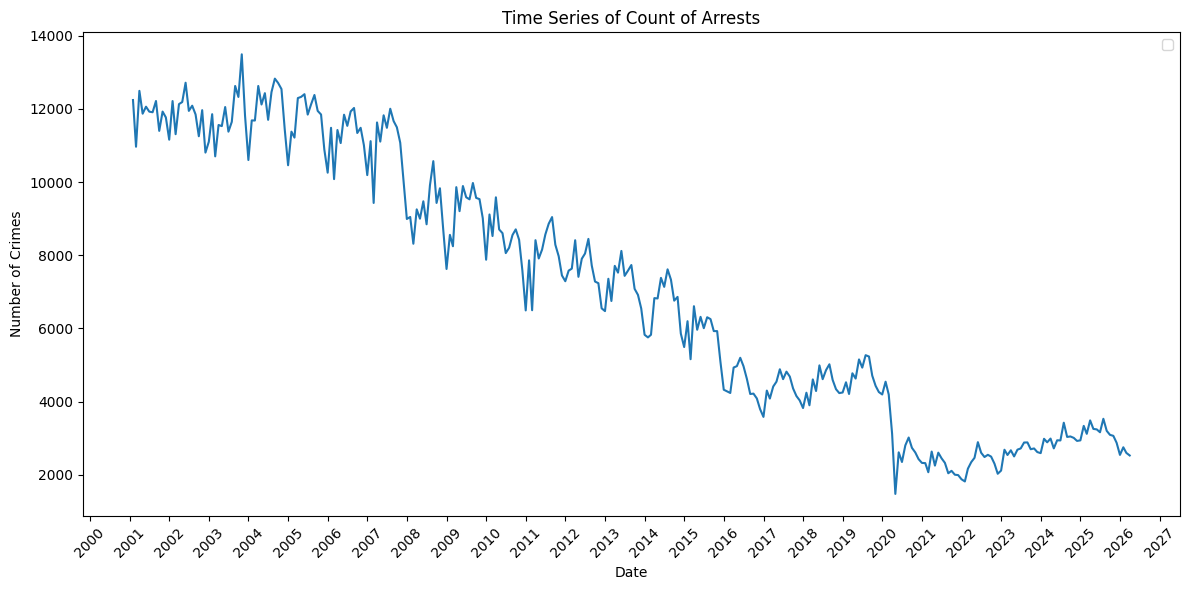

In [12]:
# Convert date column to datetime and sort
df = df[df['Arrest'] == True]

df['Date'] = pd.to_datetime(df['Date'])
df_sorted = df.sort_values('Date')



# Count murders per day
murders_per_day = df_sorted.groupby('Date').size()

# Resample to monthly counts
murders_per_month = murders_per_day.resample('M').sum()

# Create the plot (monthly, connected points)
plt.figure(figsize=(12, 6))
plt.plot(murders_per_month.index, murders_per_month.values, linestyle='-')
import matplotlib.dates as mdates
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# plt.axvline(x=pd.to_datetime('2019-04-19'), color='red', linestyle='--', label='Apr 4, 2019')
plt.xlabel('Date')
plt.ylabel('Number of Crimes')
plt.title('Time Series of Count of Arrests')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



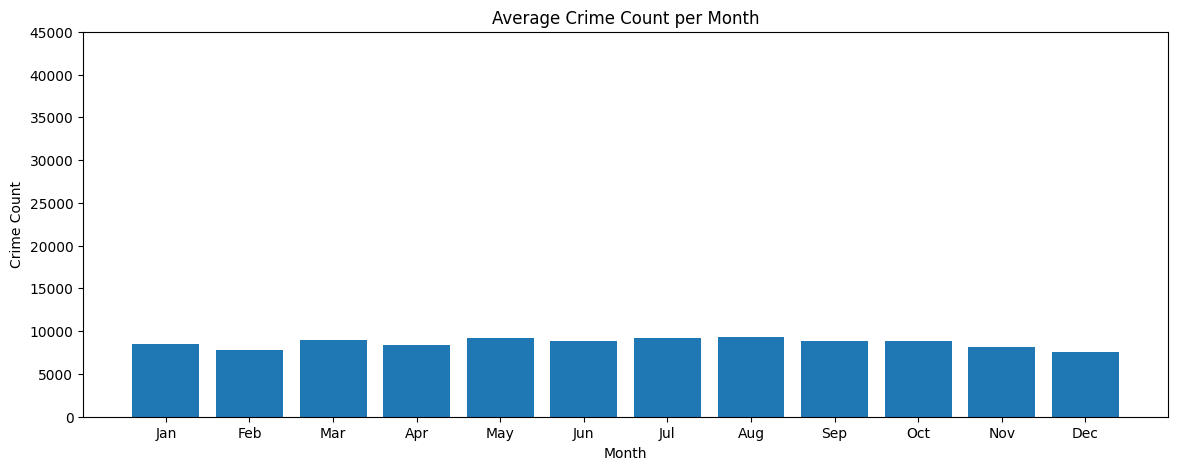

In [13]:
# Compare average murders per calendar month before and after cutoff
cutoff = pd.to_datetime('2019-04-04')
df_before = df_sorted[df_sorted['Date'] < cutoff]
df_after = df_sorted[df_sorted['Date'] >= cutoff]

# Monthly sums for each period
monthly_before = df_before.groupby(pd.Grouper(key='Date', freq='ME')).size()
monthly_after = df_after.groupby(pd.Grouper(key='Date', freq='ME')).size()

# Average by calendar month (1-12), reindex to ensure all months present
avg_by_month_before = monthly_before.groupby(monthly_before.index.month).mean().reindex(range(1,13), fill_value=0)
avg_by_month_after = monthly_after.groupby(monthly_after.index.month).mean().reindex(range(1,13), fill_value=0)

import calendar
months = [calendar.month_abbr[i] for i in range(1,13)]

plt.figure(figsize=(14,5))
plt.bar(months, avg_by_month_before.values)
plt.title('Average Crime Count per Month')
plt.ylabel('Crime Count')
plt.xlabel('Month')



plt.ylim(0, 45000)


plt.show()

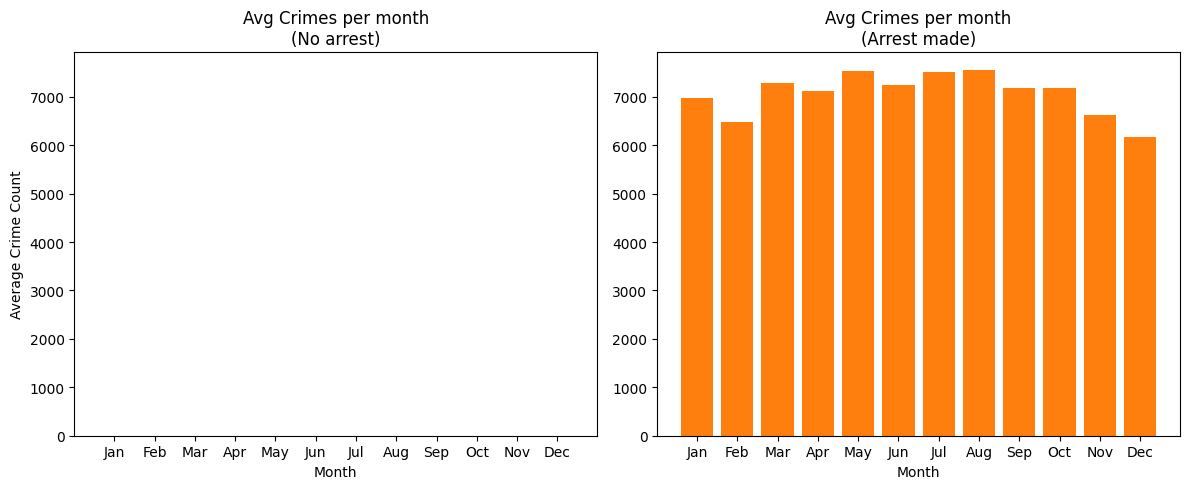

In [14]:
df['Date'] = pd.to_datetime(df['Date'])
df_sorted = df.sort_values('Date')

# Normalize Arrest to boolean (handles True/False, Yes/No, Y/N, 1/0, etc.)
df_sorted['arrest_flag'] = df_sorted['Arrest'].astype(str).str.lower().isin(
    ['true','t','y','yes','1','y','yes'])
labels = {False: 'No arrest', True: 'Arrest made'}

monthly_avg = {}
for flag in [False, True]:
    tmp = df_sorted[df_sorted['arrest_flag'] == flag]
    monthly = tmp.groupby(pd.Grouper(key='Date', freq='ME')).size()
    monthly_avg[flag] = monthly.groupby(monthly.index.month).mean().reindex(range(1,13), fill_value=0)

import calendar
months = [calendar.month_abbr[i] for i in range(1,13)]

plt.figure(figsize=(12,5))
ax1 = plt.subplot(1,2,1)
ax1.bar(months, monthly_avg[False].values, color='C0')
ax1.set_title('Avg Crimes per month\n(No arrest)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Average Crime Count')

ax2 = plt.subplot(1,2,2)
ax2.bar(months, monthly_avg[True].values, color='C1')
ax2.set_title('Avg Crimes per month\n(Arrest made)')
ax2.set_xlabel('Month')

# Use same y-axis scale for both subplots
ymax = max(monthly_avg[False].max(), monthly_avg[True].max())
ax1.set_ylim(0, ymax * 1.05)
ax2.set_ylim(0, ymax * 1.05)

plt.tight_layout()
plt.show()